In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import matlab.engine

In [6]:
# Pre-processing steps for the VAE dataset
# This is step 1, where I am only preparing the data frame to be suitable for the VAE model.

# Data preprocessing for VAE model

# Load data
df = pd.read_csv("input_VAE_allpara.csv", header=0)

# 只有存在HFtype列时才做类型转换
if 'HFtype' in df.columns:
    df['HFtype'] = df['HFtype'].astype('category').cat.codes + 1

# Convert boolean columns to integer
for col in df.columns:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)

# Remove columns with >20% missing values
missing_threshold = 0.2
missing_fraction = df.isnull().mean()
cols_to_drop_missing = missing_fraction[missing_fraction > missing_threshold].index.tolist()
df = df.drop(columns=cols_to_drop_missing)
print(f"Columns dropped due to missingness >20%: {cols_to_drop_missing}")

# Remove columns with constant values
constant_cols = [col for col in df.columns if df[col].nunique(dropna=False) == 1]
df = df.drop(columns=constant_cols)
print(f"Columns dropped due to constant value: {constant_cols}")

# Remove duplicate columns
df_T = df.T.drop_duplicates()
df = df_T.T
print("Shape after removing duplicate columns:", df.shape)

for col in df.columns:
    df[col] = df[col].apply(lambda x: np.log10(x) if pd.notnull(x) and x > 0 else np.nan)

# Impute missing values using KNN (k=5)
cols_with_missing = df.columns[df.isnull().any()].tolist()
print(f"Columns with missing values to be imputed: {cols_with_missing}")
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
if cols_with_missing:
    print(f"Imputed columns: {cols_with_missing}")
else:
    print("No columns required imputation.")

# 对连续变量反变换回原始空间
df_imputed = df_imputed.apply(lambda x: np.power(10, x))
df = df_imputed
# Round columns with <=5 unique整数值（忽略缺失）且全为整数/小数的列
rounded_cols = []
for col in df.columns:
    # 只对数值型列处理
    if pd.api.types.is_numeric_dtype(df[col]):
        unique_vals = df[col].dropna().unique()
        if len(unique_vals) <= 10:
            # 自定义分界：小数部分<0.25向下取整，>=0.25向上到0.5，>=0.75进到下一个整数，最小值为1
            vals = np.maximum(df_imputed[col], 1)
            frac = vals - np.floor(vals)
            new_vals = np.where(frac < 0.25, np.floor(vals),
                np.where(frac < 0.75, np.floor(vals) + 0.5, np.ceil(vals)))
            df_imputed[col] = new_vals
            rounded_cols.append(col)

if rounded_cols:
    print(f"Rounded columns with <=10 unique values: {rounded_cols}")
else:
    print("No columns met the <=10 unique value threshold for rounding.")


# One-hot encode multiclass categorical variables
multi_cats = []
for col in ["HFtype"]:
    if col in df.columns:
        multi_cats.append(col)
if multi_cats:
    df = pd.get_dummies(df, columns=multi_cats, drop_first=False)

# Convert one-hot back to index for true labels
hftype_cols = [col for col in df.columns if col.startswith("HFtype_")]
if hftype_cols:
    df["HFtype_index"] = df[hftype_cols].values.argmax(axis=1)
    # Drop the one-hot columns from input
    df = df.drop(columns=hftype_cols)

Columns dropped due to missingness >20%: []
Columns dropped due to constant value: []
Shape after removing duplicate columns: (408, 35)
Columns with missing values to be imputed: []
No columns required imputation.
Rounded columns with <=10 unique values: ['Sex']


In [7]:
# Pre-processing steps for the VAE dataset
# This is step 2, where I separate continuous and categorical variables and check the normality of the continuous variables.

# Categorical: columns with few unique values (e.g., <=10) or all values are integers and unique count is small.
# Continuous: columns with many unique values or float type and not binary-like.

categorical_cols = []
continuous_cols = []
unique_threshold = 10  # You can adjust this threshold as needed

for col in df.columns:
    n_unique = df[col].nunique(dropna=True)
    col_dtype = df[col].dtype
    # Heuristic: treat as categorical if unique values are small and all values are integers
    if n_unique <= unique_threshold:
        categorical_cols.append(col)
    else:
        continuous_cols.append(col)


# Will also need column indices instead of names to create tensors later:
categorical_col_indices = [df.columns.get_loc(c) for c in categorical_cols]
continuous_col_indices = [df.columns.get_loc(c) for c in continuous_cols]

# print("正态性检验（Shapiro-Wilk）结果：")
# for col in continuous_cols:
#     col_name = df.columns[col] if isinstance(col, int) else col
#     data_col = df[col_name].dropna()
#     if len(data_col) < 3:
#         print(f"{col_name}: 数据量太少，无法检验")
#         continue
#     stat, p = shapiro(data_col)
#     if p < 0.05:
#         result = "非正态 (p < 0.05)"
#     else:
#         result = "正态 (p >= 0.05)"
#     print(f"{col_name}: p = {p:.4f} -> {result}")
#     # Q-Q图
#     plt.figure(figsize=(4, 4))
#     stats.probplot(data_col, dist="norm", plot=plt)
#     plt.title(f"{col_name} Q-Q Plot")
#     plt.tight_layout()
#     plt.show()
    
## 06/10 comment: most of the continuous variables are not normally distributed, I don't know how many effects this will cause and I will try to keep unchanged first.
# Log-transform continuous variables to reduce skewness
# 只显示有小于等于0的列和数量
problem_cols = (df[continuous_cols] <= 0).sum()
problem_cols = problem_cols[problem_cols > 0]
if not problem_cols.empty:
    print("以下列存在小于等于0的值：")
    print(problem_cols)
else:
    print("所有连续变量都大于0，可以安全做log10变换。")
# 如果都为0，说明安全
df[continuous_cols] = df[continuous_cols].apply(lambda x: np.log10(x))


continuous_dims = len(continuous_cols)
categorical_dims = [
    df[col].nunique() for col in categorical_cols
]

所有连续变量都大于0，可以安全做log10变换。


In [8]:
# Get tensor for the VAE model

df["Sex"] = df["Sex"].replace({2: 0, 1: 1})

# Select data rows and columns
data = df.iloc[:,:].copy()

# Min-Max Scale continuous columns only
scaler = MinMaxScaler()
data.loc[:, continuous_cols] = scaler.fit_transform(data.loc[:, continuous_cols])

# Convert to torch.Tensor
X_train = torch.tensor(data.values, dtype=torch.float32)

print(X_train.shape)

torch.Size([408, 35])


In [9]:
# Define the AutoEncoder model for VAE
input_size = 35  # Total input features (continuous + categorical)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Set the number of hidden units
        self.num_hidden = 16
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256, self.num_hidden),
            nn.ReLU(),
        )
        
        # Decoder shared layers
        self.fc1 = nn.Linear(self.num_hidden, 256)
        self.fc2 = nn.Linear(256, 128)
        
        # Separate heads
        self.fc_continuous = nn.Linear(128, continuous_dims)
        self.fc_categoricals = nn.ModuleList([
            nn.Linear(128, cat_dim) for cat_dim in categorical_dims
        ])
        
    def forward(self, x, temperature=0.5):
        # Encode
        encoded = self.encoder(x)
        
        # Decode
        h = F.relu(self.fc1(encoded))
        h = F.relu(self.fc2(h))
        
        out_continuous = self.fc_continuous(h)
        
        out_categoricals = []
        for fc in self.fc_categoricals:
            logits = fc(h)
            out_categoricals.append(logits)
        return encoded, out_continuous, out_categoricals
    
class VAE(AutoEncoder):
    def __init__(self):
        super().__init__()
        # Add mu and log_var layers for reparameterization
        self.mu_layer = nn.Linear(self.num_hidden, self.num_hidden)
        self.log_var_layer = nn.Linear(self.num_hidden, self.num_hidden)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, temperature=0.5):
        # Encode
        encoded = self.encoder(x)
        
        # Get mu and log_var
        mu = self.mu_layer(encoded)
        log_var = self.log_var_layer(encoded)
        
        # Sample latent vector z
        z = self.reparameterize(mu, log_var)
        
        # Decode
        h = F.relu(self.fc1(z))
        h = F.relu(self.fc2(h))
        
        out_continuous = self.fc_continuous(h)
        
        out_categoricals = []
        for fc in self.fc_categoricals:
            logits = fc(h)
            out_categoricals.append(logits)    
        return z, out_continuous, out_categoricals, mu, log_var

    def sample(self, num_samples, temperature=0.5):
        with torch.no_grad():
            # Sample random z
            z = torch.randn(num_samples, self.num_hidden).to(device)
            
            # Decode
            h = F.relu(self.fc1(z))
            h = F.relu(self.fc2(h))
            
            samples_continuous = self.fc_continuous(h)
            
            samples_categoricals = []
            for fc in self.fc_categoricals:
                logits = fc(h)
                soft_sample = F.gumbel_softmax(logits, tau=temperature, hard=True)  # hard=True for discrete output
                samples_categoricals.append(soft_sample)
            
        return samples_continuous, samples_categoricals
    

def vae_kl_loss(mu, log_var):
    return -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / mu.size(0)

def autoencoder_loss(recon_continuous, true_continuous,
                     recon_categoricals, true_categoricals,
                     kl_loss, kl_weight=1e-5):
    # Continuous part
    mse_loss = F.mse_loss(recon_continuous, true_continuous, reduction='mean')
    
    # Categorical part
    cat_loss = 0
    for recon_cat, true_cat in zip(recon_categoricals, true_categoricals):
        # true_cat is [N] long tensor (category index)
        cat_loss += F.cross_entropy(recon_cat, true_cat, reduction='mean')
    cat_loss /= len(recon_categoricals)  # optional: balance contribution
    
    # Total
    total_loss = mse_loss + cat_loss + kl_weight * kl_loss
    return total_loss


In [10]:
torch.set_num_threads(4)

def train_vae(X_continuous, X_categoricals, learning_rate=3e-4, num_epochs=5000, batch_size=16, kl_weight=3e-4):
    model = VAE()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)

    train_dataset = torch.utils.data.TensorDataset(
        X_continuous,
        *X_categoricals  # Unpack the list of categorical features
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )

    recon_losses = []
    kl_losses = []
    total_losses = []

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        total_recon = 0.0
        total_kl = 0.0
        
        for batch in train_loader:
            batch_continuous = batch[0]  # first element
            batch_categoricals = list(batch[1:])  # the rest

            batch_continuous = batch_continuous.to(device)
            batch_categoricals = [b.to(device) for b in batch_categoricals]

            # 拼接输入：categorical 变量需要 unsqueeze(1) 再 float()
            input_batch = torch.cat(
                [batch_continuous] + [b.unsqueeze(1).float() for b in batch_categoricals],
                dim=1
            )
            # input_batch = torch.cat(
            # [batch_continuous] +
            # [b.unsqueeze(1).float() for b in batch_categoricals[:-1]] +  # 正常 one-hot 展开过的
            # [F.one_hot(b.squeeze(), num_classes=3).float() for b in batch_categoricals[-1:]],  # index → one-hot
            # dim=1
            # )


            encoded, recon_continuous, recon_categoricals, mu, log_var = model(input_batch, temperature=0.5)

            # KL Divergence
            kl = vae_kl_loss(mu, log_var)

            # Loss
            loss = autoencoder_loss(
                recon_continuous, batch_continuous,
                recon_categoricals, batch_categoricals,
                kl_loss=kl, kl_weight=kl_weight
            )

            # 统计recon和kl
            mse_loss = F.mse_loss(recon_continuous, batch_continuous, reduction='mean')
            cat_loss = 0
            for recon_cat, true_cat in zip(recon_categoricals, batch_categoricals):
                cat_loss += F.cross_entropy(recon_cat, true_cat, reduction='mean')
            cat_loss /= len(recon_categoricals)
            recon_loss = mse_loss + cat_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item() * batch_continuous.size(0)
            total_recon += recon_loss.item() * batch_continuous.size(0)
            total_kl += kl.item() * batch_continuous.size(0)

        epoch_loss = total_loss / len(train_loader.dataset)
        epoch_recon = total_recon / len(train_loader.dataset)
        epoch_kl = total_kl / len(train_loader.dataset)
        total_losses.append(epoch_loss)
        recon_losses.append(epoch_recon)
        kl_losses.append(epoch_kl)
        print(f"Epoch {epoch+1}/{num_epochs} — Total: {epoch_loss:.4f} | Recon: {epoch_recon:.4f} | KL: {kl_weight * epoch_kl:.4f}")

        if epoch_loss < 1e-2:
            print("Early stopping.")
            break

    # 训练结束后返回各项loss
    return model, total_losses, recon_losses, kl_losses


In [11]:
#eng = matlab.engine.start_matlab()
#eng.addpath(r'C:\Users\WHL\Documents\GitHub\Mat\TriSeg-Digital-Twins', nargout=0)

# Assume full input X_train_full (scaled already)
X_continuous = X_train[:,continuous_col_indices]  # continuous features
X_categoricals = [
    X_train[:, col_idx].long() for col_idx in categorical_col_indices
]  # list of tensors, each of shape: [408]

# Now you can train
model, total_losses, recon_losses, kl_losses = train_vae(X_continuous, X_categoricals)

Epoch 1/5000 — Total: 0.9191 | Recon: 0.9190 | KL: 0.0001
Epoch 2/5000 — Total: 0.7628 | Recon: 0.7626 | KL: 0.0002
Epoch 3/5000 — Total: 0.7342 | Recon: 0.7340 | KL: 0.0002
Epoch 4/5000 — Total: 0.7084 | Recon: 0.7082 | KL: 0.0002
Epoch 3/5000 — Total: 0.7342 | Recon: 0.7340 | KL: 0.0002
Epoch 4/5000 — Total: 0.7084 | Recon: 0.7082 | KL: 0.0002
Epoch 5/5000 — Total: 0.6501 | Recon: 0.6498 | KL: 0.0003
Epoch 6/5000 — Total: 0.5067 | Recon: 0.5062 | KL: 0.0005
Epoch 5/5000 — Total: 0.6501 | Recon: 0.6498 | KL: 0.0003
Epoch 6/5000 — Total: 0.5067 | Recon: 0.5062 | KL: 0.0005
Epoch 7/5000 — Total: 0.2899 | Recon: 0.2891 | KL: 0.0008
Epoch 8/5000 — Total: 0.1250 | Recon: 0.1237 | KL: 0.0013
Epoch 7/5000 — Total: 0.2899 | Recon: 0.2891 | KL: 0.0008
Epoch 8/5000 — Total: 0.1250 | Recon: 0.1237 | KL: 0.0013
Epoch 9/5000 — Total: 0.0610 | Recon: 0.0594 | KL: 0.0016
Epoch 10/5000 — Total: 0.0584 | Recon: 0.0566 | KL: 0.0018
Epoch 9/5000 — Total: 0.0610 | Recon: 0.0594 | KL: 0.0016
Epoch 10/5000

In [13]:
# 用训练集输入VAE，查看重建效果
model.eval()
with torch.no_grad():
    # 构造输入：连续+分类
    input_batch = torch.cat(
    [X_train[:, continuous_col_indices]] +
    [X_train[:, col_idx].unsqueeze(1).float() for col_idx in categorical_col_indices],  # 其他分类变量
    dim=1
)
    # 前向传播
    z, recon_continuous, recon_categoricals, mu, log_var = model(input_batch)
    # 分类输出取argmax
    recon_categorical_indices = [torch.argmax(logits, dim=1) for logits in recon_categoricals]
    # 还原数据
    recon_columns = []
    cont_idx = 0
    cat_idx = 0
    for col_idx in range(X_train.shape[1]):
        if col_idx in categorical_col_indices:
            recon_columns.append(recon_categorical_indices[cat_idx].unsqueeze(1))
            cat_idx += 1
        else:
            recon_columns.append(recon_continuous[:, cont_idx].unsqueeze(1))
            cont_idx += 1
    recon_tensor = torch.cat(recon_columns, dim=1)
    recon_np = recon_tensor.cpu().numpy()
    # 反归一化连续变量
    recon_np_original = recon_np.copy()
    recon_np_original[:, continuous_col_indices] = scaler.inverse_transform(recon_np[:, continuous_col_indices])

    max_log10 = 4.816  # 或你认为合理的最大log10值
    no_clip_cols = ['k_pas_LV', 'k_pas_RV', 'k_act_LV', 'k_act_RV'] 
    clip_cols = [col for col in continuous_cols if col not in no_clip_cols]
    clip_col_indices = [df.columns.get_loc(col) for col in clip_cols]
    no_clip_col_indices = [df.columns.get_loc(col) for col in no_clip_cols]

    # DataFrame写法
    df_clip = recon_np_original.copy()
    for idx in clip_col_indices:
        recon_np_original[:, idx] = np.power(10, np.clip(recon_np_original[:, idx], None, max_log10))
    for idx in no_clip_col_indices:
        recon_np_original[:, idx] = np.power(10, recon_np_original[:, idx])

    # 同步对原始df的连续变量做反log10变换
    if isinstance(df, pd.DataFrame):
        df_original = df.copy()
        df_original.iloc[:, continuous_col_indices] = np.power(10, df.iloc[:, continuous_col_indices])
        print("df_original已恢复为原始物理量级")
    else:
        print("df 不是DataFrame，无法反log10变换")

    df_original["Sex"] = df_original["Sex"].replace({2: 0, 1: 1})
    # 保存或查看
    df_recon = pd.DataFrame(recon_np_original, columns=df.columns)
    df_recon.to_csv("vae_reconstruction_on_train.csv", index=False)
    print("重建数据已保存为 vae_reconstruction_on_train.csv")
    df_recon.head()

df_original已恢复为原始物理量级
重建数据已保存为 vae_reconstruction_on_train.csv


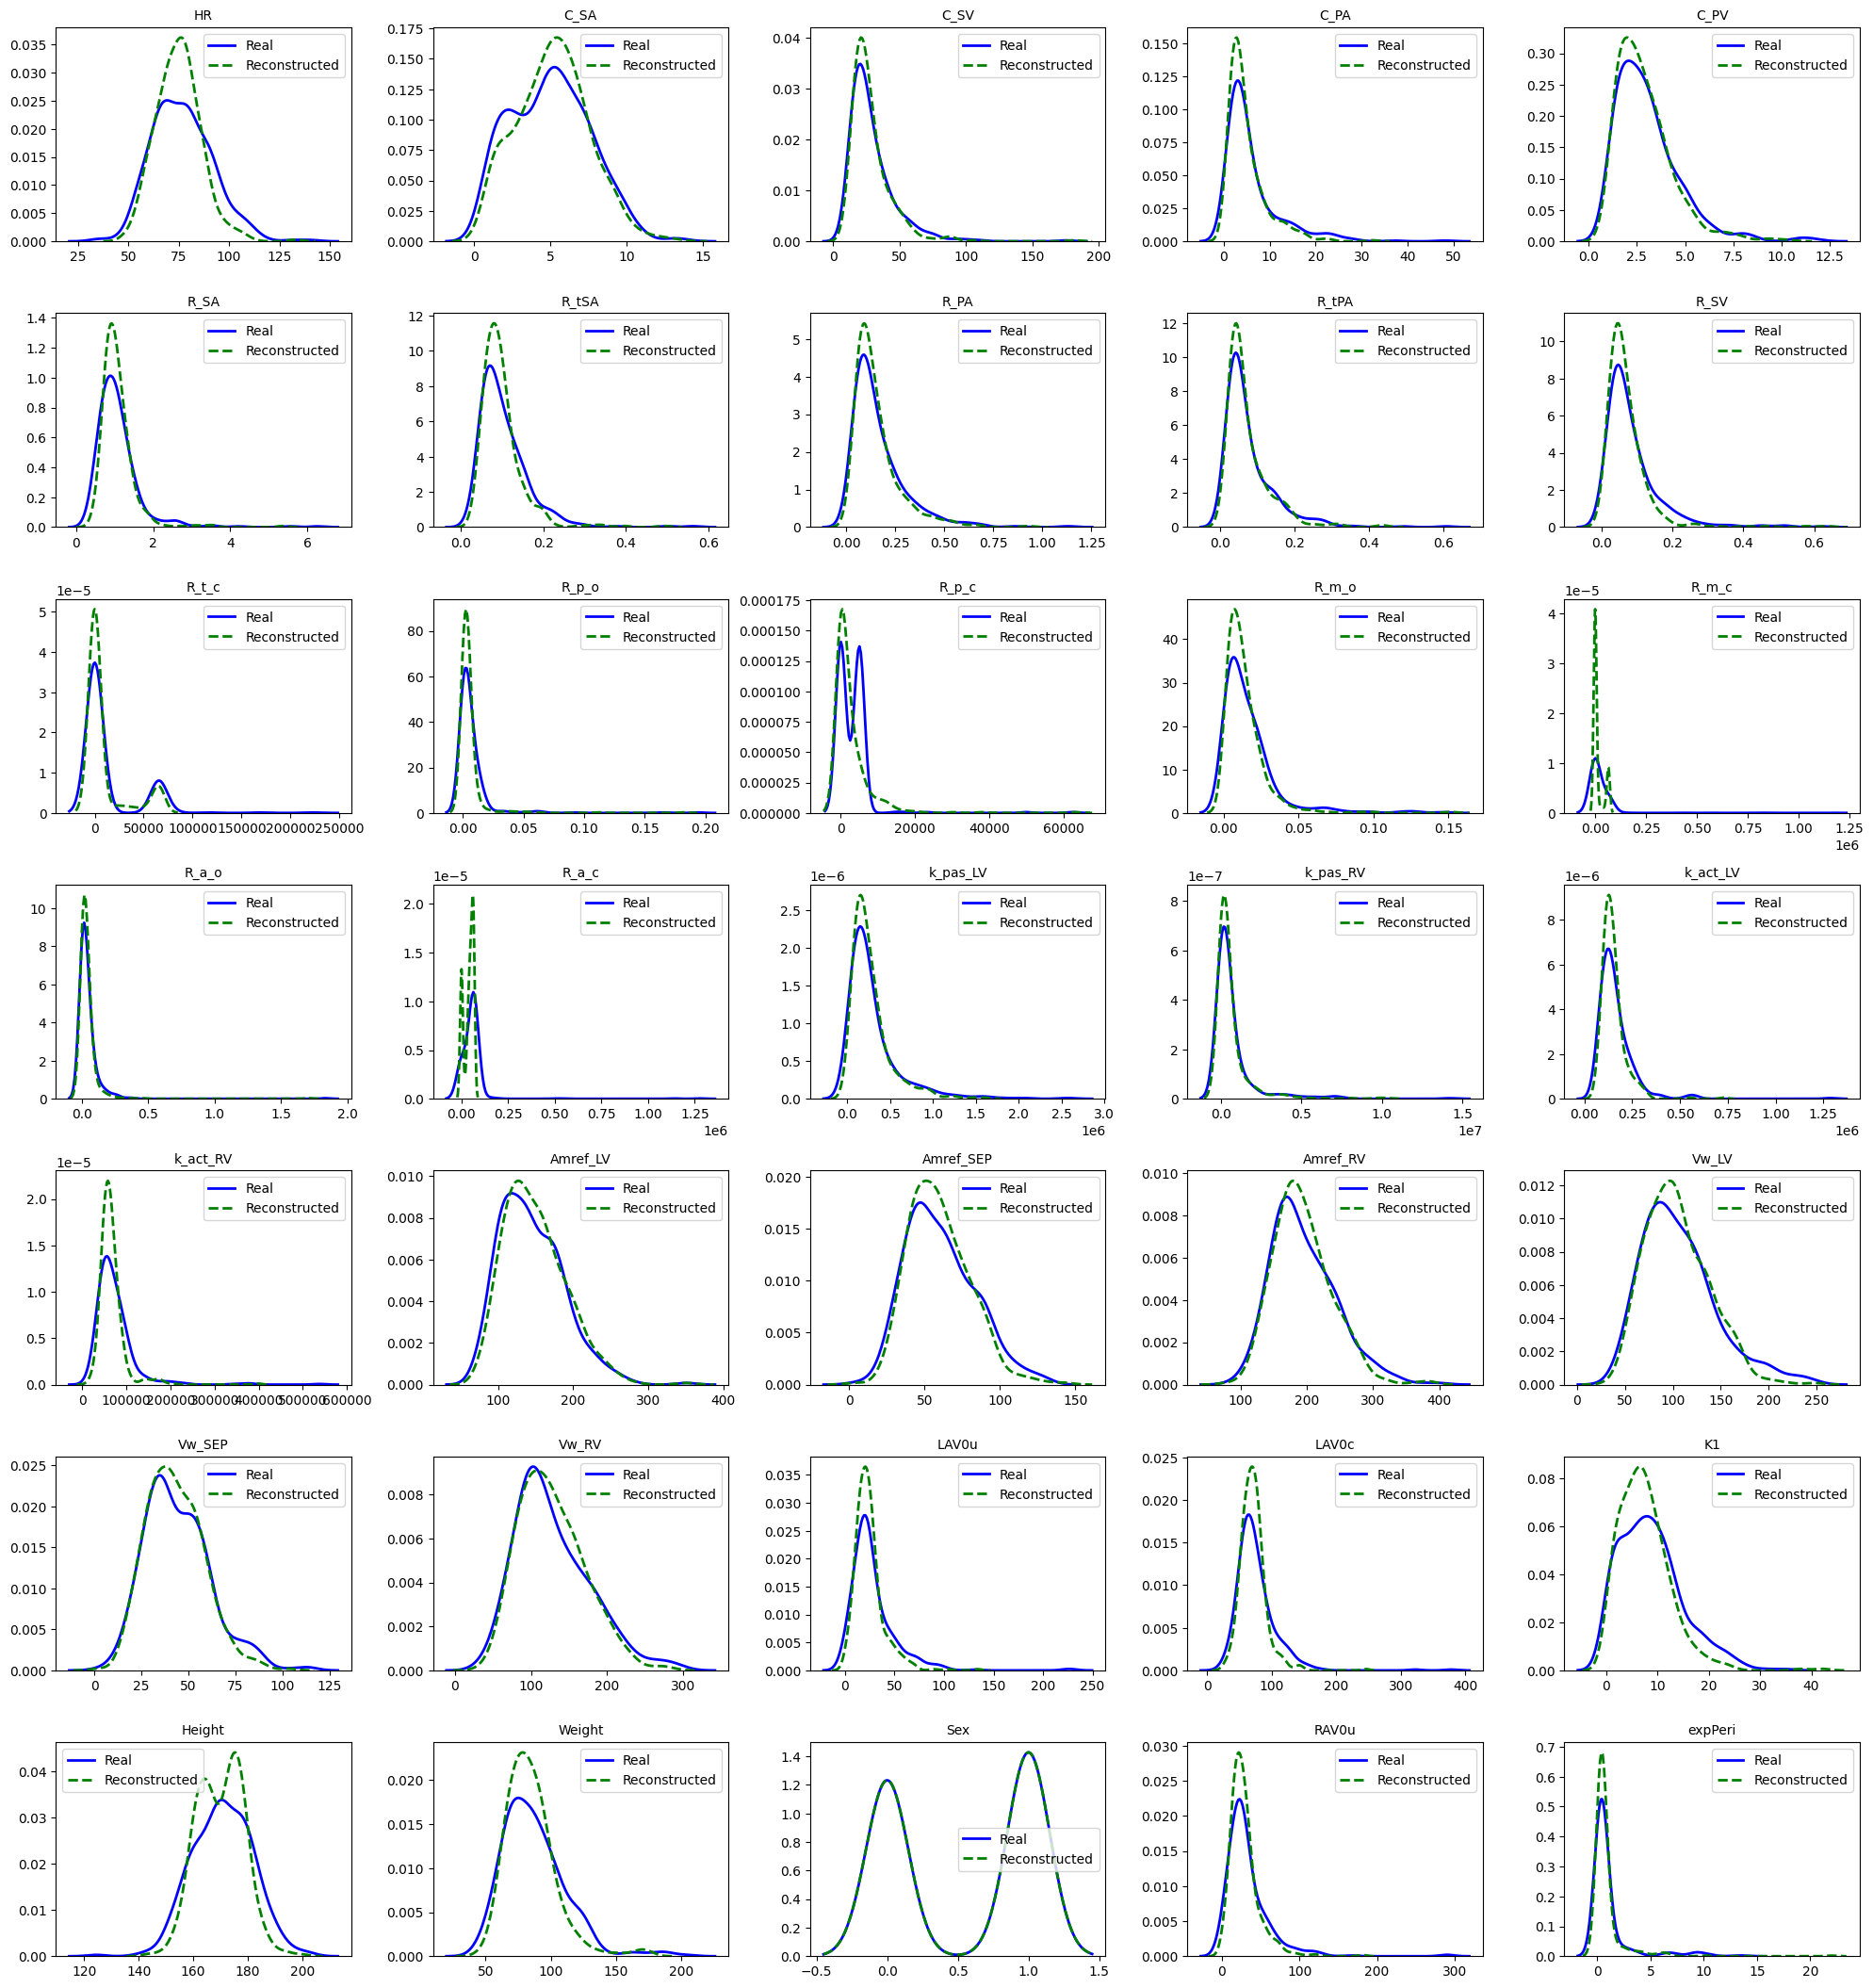

In [14]:
# 读取重建数据
recon_data = pd.read_csv("vae_reconstruction_on_train.csv")

# 只画前35个变量
num_cols = 35
cols_to_plot = df_original.columns[:num_cols]

fig, axes = plt.subplots(nrows=num_cols // 5 + 1, ncols=5, figsize=(20, 3 * (num_cols // 5 + 1)))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.kdeplot(df_original[col], ax=axes[i], label="Real", color="blue", linewidth=2)
    sns.kdeplot(recon_data[col], ax=axes[i], label="Reconstructed", color="green", linestyle="--", linewidth=2)
    axes[i].set_title(f"{col}", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("VAE_reconstruction_PDF_CC.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
model.eval()
with torch.no_grad():
    N = int(1e3)  # Number of samples to generate
    samples_continuous, samples_categoricals = model.sample(N, temperature=0.1)

    # Step 1: Argmax for all categoricals
    samples_categorical_indices = [torch.argmax(c, dim=1) for c in samples_categoricals]

# Step 2: Rebuild the fake data column by column
fake_data_columns = []

# Counters
continuous_counter = 0
categorical_counter = 0

for col_idx in range(35):
    if col_idx in categorical_col_indices:
        # Take from categorical sampled indices
        fake_data_columns.append(samples_categorical_indices[categorical_counter].unsqueeze(1))
        categorical_counter += 1
    else:
        # Take from continuous sampled outputs
        fake_data_columns.append(samples_continuous[:, continuous_counter].unsqueeze(1))
        continuous_counter += 1

# Stack into full fake data
fake_data_tensor = torch.cat(fake_data_columns, dim=1)
fake_data_np = fake_data_tensor.cpu().numpy()

# Step 3: Inverse transform continuous columns only
fake_data_original_scale = fake_data_np.copy()

# Continuous cols inverse transform
fake_data_original_scale[:, continuous_col_indices] = scaler.inverse_transform(
    fake_data_np[:, continuous_col_indices]
)
for idx in clip_col_indices:
    fake_data_original_scale[:, idx] = np.power(10, np.clip(fake_data_original_scale[:, idx], None, max_log10))
for idx in no_clip_col_indices:
    fake_data_original_scale[:, idx] = np.power(10, fake_data_original_scale[:, idx])
# Step 5: Save
df_fake = pd.DataFrame(fake_data_original_scale, columns=df.columns)
df_fake.to_csv("generated_fake_data_2.csv", index=False)

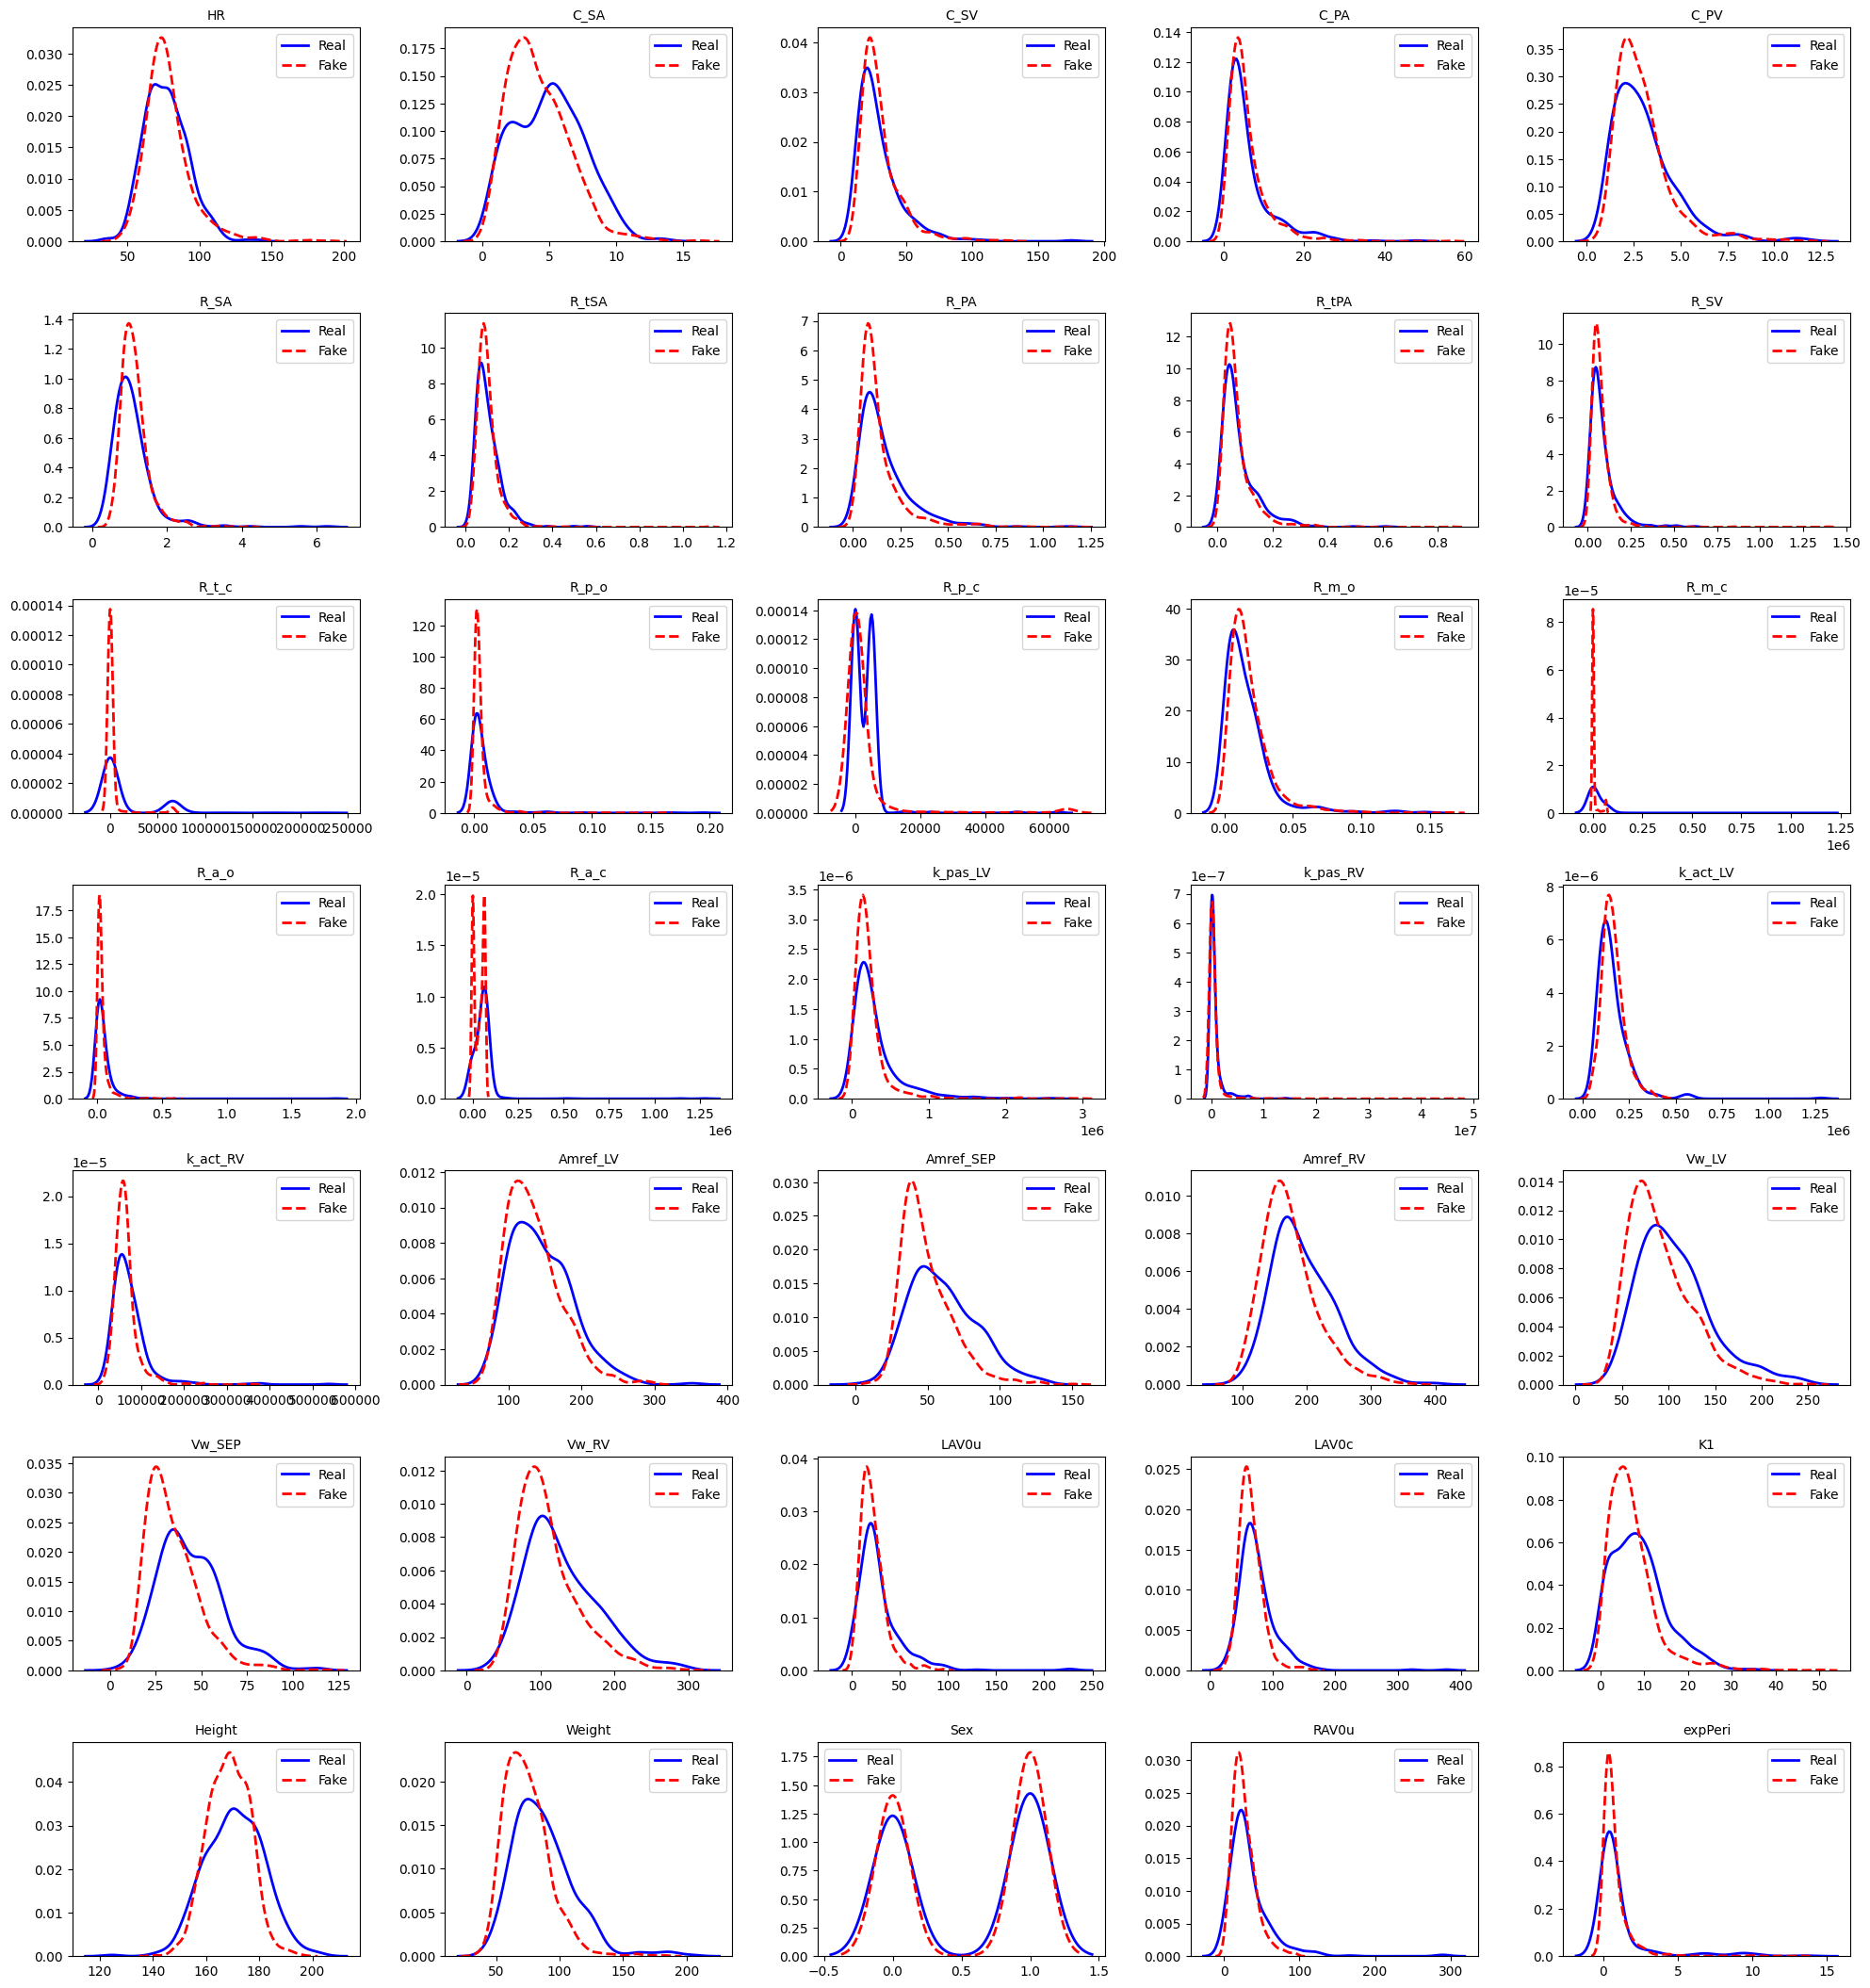

In [17]:

# Plot only the first 35 columns
num_cols = 35
cols_to_plot = df_original.columns[:num_cols]

# Set up subplot grid
fig, axes = plt.subplots(nrows=num_cols // 5 + 1, ncols=5, figsize=(20, 3 * (num_cols // 5 + 1)))
axes = axes.flatten()

# Plot each feature's KDE for real and fake
for i, col in enumerate(cols_to_plot):
    sns.kdeplot(df_original[col], ax=axes[i], label="Real", color="blue", linewidth=2)
    sns.kdeplot(df_fake[col], ax=axes[i], label="Fake", color="red", linestyle="--", linewidth=2)
    axes[i].set_title(f"{col}", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].legend()

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("Fakedata_PDF_CC.png", dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# 读取数据
df_fake = pd.read_csv("generated_fake_data_2.csv")
input_data = df_fake.iloc[:, :35].to_numpy()

# 启动 MATLAB 引擎
eng = matlab.engine.start_matlab()

labels = []
batch_size = 10
n = input_data.shape[0]

for i in range(0, n, batch_size):
    batch = input_data[i:i+batch_size]
    # 如果最后一批不满4行，自动补全为4行或让matlab函数能容忍
    if batch.shape[0] < batch_size:
        # 补齐最后一批，用0或其它合适的值填充
        pad = np.zeros((batch_size - batch.shape[0], batch.shape[1]))
        batch = np.vstack([batch, pad])
        matlab_input = matlab.double(batch.tolist())
        batch_labels = eng.simulate_batch_parallel(matlab_input)
        # 只保留真实长度部分
        labels.extend(batch_labels[:batch.shape[0] - pad.shape[0]])
        print(f"Processed samples: {min(i+batch_size, n)}/{n}")
    else:
        matlab_input = matlab.double(batch.tolist())
        batch_labels = eng.simulate_batch_parallel(matlab_input)
        labels.extend(batch_labels)
        print(f"Processed samples: {min(i+batch_size, n)}/{n}")

labels = np.array(labels).flatten()
df_fake['label'] = labels

eng.quit()

print(df_fake[['label']].head())
df_fake.to_csv("output_labeled.csv", index=False)
print("\n已保存所有结果到 output_labeled.csv")

Processed samples: 10/1000


TypeError: 'NoneType' object is not iterable